# Simulating leakage and atom loss in clifft

Real qubits do not stay in their two-dimensional computational subspace. An atom can be
excited into a state outside the qubit manifold (**leakage**) or disappear from its trap
entirely (**loss**). Both processes matter enormously for quantum error correction --
they produce errors that ordinary Pauli noise models cannot represent -- and both are
awkward for fast stabilizer simulators, whose formalism only knows about qubits.

This notebook walks through clifft's *noncomputational* simulation path end to end:

1. the physics being modeled, and where exact simulation ends and approximation begins;
2. the Python API, one physical scenario at a time, each paired with a check against a
   closed-form expectation;
3. a realistic neutral-atom-style noise model on a small error-correction circuit;
4. a summary of what noise modeling is possible, exactly or approximately, and what is
   deliberately out of scope.

Everything here is self-contained: every quantitative claim is produced by the cell that
makes it, with fixed seeds.

If you already work with a transition-matrix leakage simulator (for example the one in
cirq-superstaq), the **appendix** maps each of its concepts onto this API directly, and
section 1 will read as familiar ground.

## 1. The physics: an extended state space

Standard circuit simulation works in a computational subspace $\mathcal{H}_C \cong \mathbb{C}^2$
per site. To model leakage and loss we extend each site:

$$\mathcal{H}_\text{tot} = \mathcal{H}_C \oplus \mathcal{H}_{NC}$$

clifft's built-in model gives every qubit **five levels**:

| index | name | category | meaning |
|---|---|---|---|
| 0 | `g` | computational | the qubit state $\lvert 0\rangle$ |
| 1 | `e` | computational | the qubit state $\lvert 1\rangle$ |
| 2 | `leak_g` | leaked | carrier present, outside the qubit manifold |
| 3 | `leak_e` | leaked | a second leaked level |
| 4 | `lost` | lost | carrier physically gone |

The two noncomputational categories are physically distinct. A **leaked** atom is still
in the trap: later pulses address an empty transition (they do nothing to it), but the
site exists. A **lost** atom is structurally absent: any multi-qubit interaction with
that site simply does not happen. Occupation of the noncomputational levels is tracked
as *classical* per-qubit status -- the model deliberately does not keep coherences into
or inside $\mathcal{H}_{NC}$ (that regime needs a full qudit simulation).

**Transitions** between levels are specified per gate as a matrix $T[\text{to},\text{from}]$:
column $s$ gives the probabilities of jumping out of level $s$ when the gate fires, and the
column's deficit below one is the probability that nothing happens. In Kraus language each
entry is a jump operator $\sqrt{p_{s\to d}}\,|d\rangle\langle s|$, with the no-jump
back-action as the complement. A **measurement classifier** maps the level at readout to
the recorded symbol -- including a third *herald* symbol for detected loss.

### What samples exactly, and what cannot

clifft compiles a circuit once and samples many shots. Loss and leakage are handled
*ahead of time*: each shot draws a classical trajectory (which transitions fired, where),
rewrites the circuit for that trajectory -- removing gates on lost sites, inserting the
hidden collapse operations that implement the partial trace -- and runs the rewritten
circuit through the ordinary exact simulator.

Whether that classical pre-sampling is *exact* depends on one property of the transition
matrix. If the computational columns are equal (**state-independent** transitions), the
no-jump back-action is proportional to the identity, the jump probability does not depend
on the quantum amplitudes, and pre-sampling is exact. If they differ
(**state-dependent**, e.g. leakage only out of $|1\rangle$), the jump probability depends
on the state, the no-jump branch filters amplitudes, and *no* classical pre-sampling can
be exact. For that case clifft offers an explicit, opt-in **equalized-rates
approximation** -- pad the lower-rate column with a "pseudo-jump" that only dephases, so
all computational columns share the maximum rate -- whose accuracy envelope is
demonstrated, not just stated, in section 2.5.

One more piece of bookkeeping matters for those demos: clifft's trajectory sampler knows a
qubit's level only when an *instruction* pins it (after a reset, or before any gate). A
qubit that a sequence of gates happens to return to a definite state is still tracked as
"unknown". Where that distinction bites is also shown below.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import clifft
from clifft import noncomp, twirl

Level = noncomp.Level
SHOTS = 20_000


# Build a 5x5 transition matrix T[to][from] from {(to, from): p}.
def T(entries: dict) -> list[list[float]]:
    m = [[0.0] * 5 for _ in range(5)]
    for (to, frm), p in entries.items():
        m[to][frm] = p
    return m


# Classifier: g/leak_g read 0, e/leak_e read 1 (with optional confusion), lost heralds.
def ternary_classifier(leak_confusion: float = 0.0) -> noncomp.Classifier:
    m = [[0.0] * 5 for _ in range(3)]
    m[0][Level.G] = m[1][Level.E] = 1.0
    m[0][Level.LEAK_G], m[1][Level.LEAK_G] = 1 - leak_confusion, leak_confusion
    m[1][Level.LEAK_E], m[0][Level.LEAK_E] = 1 - leak_confusion, leak_confusion
    m[2][Level.LOST] = 1.0
    return noncomp.Classifier(["0", "1", "2"], m)


print("clifft", clifft.version())

clifft 0.4.2.dev17+ge9f424da4.d20260611


## 2. The API, one physical scenario at a time

### 2.1 Initial populations and the status sidecar

A model is a per-level initial distribution, per-gate transition matrices, a classifier,
and policy knobs. `noncomp.sample` returns the usual records plus two sidecars: each
qubit's final status, and a per-measurement herald flag. `symbols()` folds the herald
back into a ternary per-slot view.

In [2]:
model = noncomp.Model(
    initial_state=[0.95, 0.00, 0.02, 0.01, 0.02],  # P(g, e, leak_g, leak_e, lost)
    classifier=ternary_classifier(),
)
r = noncomp.sample("M 0\n", model, shots=SHOTS, seed=1)

status = r.final_status[:, 0]
print(
    "status fractions (computational, leaked, lost):",
    [round(float((status == k).mean()), 4) for k in range(3)],
)
print("expected:                                      ", [0.95, 0.03, 0.02])
print("ternary readout counts (0/1/2):", [int((r.symbols()[:, 0] == v).sum()) for v in (0, 1, 2)])
assert abs((status == noncomp.QubitStatusKind.LOST).mean() - 0.02) < 0.005

status fractions (computational, leaked, lost): [0.9513, 0.0297, 0.019]
expected:                                       [0.95, 0.03, 0.02]
ternary readout counts (0/1/2): [19430, 190, 380]


### 2.2 Loss is a partial trace

The first physics claim worth testing: when an entangled qubit is lost, the survivor must
be left in the reduced (partially traced) state. For a Bell pair that is the maximally
mixed state -- the survivor reads 0 or 1 with probability $\tfrac12$, *uncorrelated* with
the lost atom's record. Internally the rewriter implements this with a hidden collapse
inserted at the loss event; nothing about it leaks into the visible record layout.

In [3]:
lossy = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0],
    transitions={"S": T({(Level.LOST, Level.G): 1.0, (Level.LOST, Level.E): 1.0})},
    classifier=ternary_classifier(),
)
# Bell pair, then the hooked S loses qubit 0 with certainty.
r = noncomp.sample("H 0\nCX 0 1\nS 0\nM 0\nM 1\n", lossy, shots=SHOTS, seed=2)

survivor = r.measurements[:, 1]
print("survivor P(1) =", round(float(survivor.mean()), 4), " (partial trace: 0.5)")
print("lost qubit heralds:", bool(np.all(r.heralds[:, 0] == 1)))
assert abs(survivor.mean() - 0.5) < 0.01

survivor P(1) = 0.5037  (partial trace: 0.5)
lost qubit heralds: True


### 2.3 Relaxation and recapture re-prepare the carrier

Transition matrices may also have *computational* destinations: relaxation (any level
decaying back to `g`) or recapture of a lost atom. clifft materializes the carrier at the
destination -- the channel $\rho \mapsto |d\rangle\langle d| \otimes \mathrm{Tr}_q(\rho)$ --
so a collapse-to-$g$ with probability $p$ on a $|+\rangle$ state leaves
$P(M{=}1) = (1-p)\cdot\tfrac12$:

In [4]:
p = 0.3
relax = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0],
    transitions={"S": T({(Level.G, Level.G): p, (Level.G, Level.E): p})},
)
r = noncomp.sample("H 0\nS 0\nM 0\n", relax, shots=SHOTS, seed=3)
print(f"P(M=1) = {r.measurements[:, 0].mean():.4f}   (analytic: {(1 - p) / 2})")
assert abs(r.measurements[:, 0].mean() - (1 - p) / 2) < 0.01

P(M=1) = 0.3528   (analytic: 0.35)


### 2.4 Readout: classifiers, heralds, and detectors

The classifier's columns give $P(\text{symbol} \mid \text{level})$ at measurement. A lost
site reads the herald symbol, reported in the `heralds` sidecar while the visible record
keeps a uniformly drawn bit -- so the record layout (and every `rec[-k]` reference) is
unchanged, and downstream `DETECTOR`s keep working. Crucially, the classifier's bit is
injected *before* detector evaluation inside the simulator, so leakage shows up as
detector events, which is the whole point for error correction:

In [5]:
leaky = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0],
    transitions={"S": T({(Level.LEAK_E, Level.G): 1.0, (Level.LEAK_E, Level.E): 1.0})},
    classifier=ternary_classifier(),  # leak_e reads 1
)
# A reference measurement, then the leaked one; the detector XORs them.
r = noncomp.sample("M 1\nH 0\nS 0\nM 0\nDETECTOR rec[-1] rec[-2]\n", leaky, shots=SHOTS, seed=4)
print(
    "P(detector fires) =",
    round(float(r.detectors[:, 0].mean()), 4),
    " (leaked qubit always reads 1, reference always 0)",
)
assert np.all(r.detectors[:, 0] == 1)

P(detector fires) = 1.0  (leaked qubit always reads 1, reference always 0)


### 2.5 State-dependent transitions: the equalized-rates approximation, with its boundary

Suppose only $|1\rangle$ leaks (a state-dependent matrix) and the qubit is in
$|+\rangle$. Exact treatment requires runtime access to amplitudes, so by default clifft
**refuses** -- approximation is never silent. Opting in to
`unknown_source_policy="equalize_rates"` enables the standard fast-path approximation:
both computational columns are padded to the maximum rate $p$, the source is drawn
uniformly, and every fired jump collapses the carrier (the padding events are pure
dephasing). For a leak that reads 1, the analytic prediction on $|+\rangle$ is
$P(M{=}1) = \tfrac{p}{2} + \tfrac{p}{2} + \tfrac{1-p}{2} = \tfrac12 + \tfrac{p}{2}$:

In [6]:
p = 0.4
leak_from_g = {"S": T({(Level.LEAK_E, Level.G): p})}  # leaks only out of g

strict = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0], transitions=leak_from_g, classifier=ternary_classifier()
)
try:
    noncomp.sample("H 0\nS 0\nM 0\n", strict, shots=4, seed=5)
except ValueError as err:
    print("default policy refuses:", str(err)[:80], "...")

approx = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0],
    transitions=leak_from_g,
    classifier=ternary_classifier(),
    unknown_source_policy="equalize_rates",
)
r = noncomp.sample("H 0\nS 0\nM 0\n", approx, shots=SHOTS, seed=5)
print(f"P(M=1) = {r.measurements[:, 0].mean():.4f}   (analytic: {0.5 + p / 2})")
leaked = (r.final_status[:, 0] == noncomp.QubitStatusKind.LEAKED).mean()
print(f"P(leaked) = {leaked:.4f}   (analytic: {p / 2})")
assert abs(r.measurements[:, 0].mean() - (0.5 + p / 2)) < 0.01

default policy refuses: sample_history: source-dependent transition on gate 'S' fired on ComputationalUn ...
P(M=1) = 0.6979   (analytic: 0.7)
P(leaked) = 0.1993   (analytic: 0.2)


The approximation has a precisely characterized envelope. **Per-qubit marginals are exact
whenever the source is genuinely unbiased** (which a stabilizer state always is, when it
is not outright deterministic). What it gives up is twofold, and both halves can be shown
live rather than asserted.

**(a) Joint correlations.** If the leak destination depends on the source level
($g \to$ `leak_g` reads 0, $e \to$ `leak_e` reads 1), an exact treatment of a Bell pair
would correlate the leaked atom's readout with its partner. The equalized draw picks the
source independently of the collapse, so the joint distribution factorizes -- every
marginal is right, the correlation is gone:

In [7]:
pair_model = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0],
    transitions={"S": T({(Level.LEAK_G, Level.G): 1.0, (Level.LEAK_E, Level.E): 1.0})},
    classifier=ternary_classifier(),
    unknown_source_policy="equalize_rates",
)
r = noncomp.sample("H 0\nCX 0 1\nS 0\nM 0\nM 1\n", pair_model, shots=SHOTS, seed=6)
m = r.measurements
print(
    "marginals:",
    round(float(m[:, 0].mean()), 3),
    round(float(m[:, 1].mean()), 3),
    " (exact treatment: 0.5, 0.5)",
)
print(
    "P(records equal) =",
    round(float((m[:, 0] == m[:, 1]).mean()), 3),
    " (exact treatment would give 1.0)",
)

marginals: 0.502 0.495  (exact treatment: 0.5, 0.5)
P(records equal) = 0.5  (exact treatment would give 1.0)


**(b) Gate-determined states.** Status tracking is instruction-known, so two Hadamards
return a qubit to $|0\rangle$ physically while the tracker still says "unknown". The
exact channel below (leaking only out of $e$) could never fire on $|0\rangle$; the
equalized draw still leaks half of its fires. This is deliberately pinned by a test in
the repository so the boundary cannot drift silently:

In [8]:
p = 0.6
gate_determined = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0],
    transitions={"S": T({(Level.LEAK_E, Level.E): p})},
    classifier=ternary_classifier(),
    unknown_source_policy="equalize_rates",
)
r = noncomp.sample("H 0\nH 0\nS 0\nM 0\n", gate_determined, shots=SHOTS, seed=7)
leaked = (r.final_status[:, 0] == noncomp.QubitStatusKind.LEAKED).mean()
print(f"P(leaked) = {leaked:.4f}   (exact channel: 0.0; equalized: {p / 2})")

P(leaked) = 0.2944   (exact channel: 0.0; equalized: 0.3)


### 2.6 What happens downstream of a leaked or lost site

By default, an operation touching a leaked or lost operand that has no representable
effect there is **refused** -- again, no silent choices. Opting in to
`lost_leaked_ops="drop"` excises such operations whole (identity on the surviving
operands): the physical interaction cannot happen at a vacated site. Measurements are
never dropped, so the record layout survives; transitions still fire (a lost atom's
neighbors keep their own noise). With both compatibility policies on, multi-round
error-correction circuits run through loss events end to end:

In [9]:
circuit = "H 0\nS 0\nCX 0 1\nMR 1\nCX 0 1\nMR 1\nM 0\n"
lose_data = {"S": T({(Level.LOST, Level.G): 1.0, (Level.LOST, Level.E): 1.0})}

strict = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0], transitions=lose_data, classifier=ternary_classifier()
)
try:
    noncomp.sample(circuit, strict, shots=4, seed=8)
except ValueError as err:
    print("default policy refuses:", str(err)[:80], "...")

compat = noncomp.Model(
    initial_state=[1, 0, 0, 0, 0],
    transitions=lose_data,
    classifier=ternary_classifier(),
    lost_leaked_ops="drop",
)
r = noncomp.sample(circuit, compat, shots=8, seed=8)
print("ternary records (ancilla, ancilla, data):")
print(r.symbols()[:4])  # both CXs dropped: ancilla stays 0; the lost data heralds

default policy refuses: rewrite: operation 'CX' on a Lost qubit 0 at op 2 is not representable; rejectin ...
ternary records (ancilla, ancilla, data):
[[0 0 2]
 [0 0 2]
 [0 0 2]
 [0 0 2]]


### 2.7 Coherent control errors: twirl them, or simulate them exactly

Over-rotations and phase miscalibrations are unitaries, not status changes, so they stay
outside the noncomputational model. The `clifft.twirl` helpers convert them into the
standard Pauli-twirl channel $p_P = |\mathrm{tr}(U P)|^2 / 4$, inserted as ordinary noise
instructions. The twirl preserves the Pauli-transfer-matrix diagonal -- *not* circuit
statistics. Sometimes that coincides with exact; in general it does not, and because
clifft simulates non-Clifford gates exactly (at active-rank cost), both sides of that
boundary can be measured in one place:

In [10]:
S_MATRIX = np.array([[1, 0], [0, 1j]])
H_MATRIX = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
pz = twirl.pauli_probabilities(S_MATRIX)[2]
px_h, py_h, pz_h = twirl.pauli_probabilities(H_MATRIX)


def p1(text: str) -> float:
    return float(clifft.sample(clifft.compile(text), SHOTS, 9).measurements[:, 0].mean())


cases = [
    (
        "one S between Hadamards (twirl matches here)",
        "H 0\nS 0\nH 0\nM 0\n",
        f"H 0\nZ_ERROR({pz}) 0\nH 0\nM 0\n",
    ),
    (
        "two S = exact Z (coherent accumulation)",
        "H 0\nS 0\nS 0\nH 0\nM 0\n",
        f"H 0\nZ_ERROR({pz}) 0\nZ_ERROR({pz}) 0\nH 0\nM 0\n",
    ),
    (
        "H then twirled H (a single application differs)",
        "H 0\nH 0\nM 0\n",
        f"H 0\nPAULI_CHANNEL_1({px_h}, {py_h}, {pz_h}) 0\nM 0\n",
    ),
]
for label, exact_text, twirled_text in cases:
    print(f"{label}:\n   exact P(1) = {p1(exact_text):.3f}   twirled P(1) = {p1(twirled_text):.3f}")

one S between Hadamards (twirl matches here):
   exact P(1) = 0.505   twirled P(1) = 0.500
two S = exact Z (coherent accumulation):
   exact P(1) = 1.000   twirled P(1) = 0.501
H then twirled H (a single application differs):
   exact P(1) = 0.000   twirled P(1) = 0.494


## 3. A realistic neutral-atom noise model, end to end

Parameter magnitudes follow what Infleqtion reported for their cesium-atom platform in
the two-logical-qubit experiment ([arXiv:2412.07670](https://arxiv.org/abs/2412.07670)):
per-two-qubit-gate leakage out of the excited state at the $10^{-3}$ scale with a few
$10^{-3}$ atom loss, single-qubit-layer leakage near $10^{-3}$, readout confusion of
0.4--2.8%, and a ~1% relative over-rotation (twirled here; section 2.7 showed exactly
what that approximation costs).

The circuit is a distance-5 repetition-code memory: data in superposition, five rounds of
CX syndrome extraction with measure-and-reset ancillas, a hooked single-qubit layer on
the data each round, and detectors comparing consecutive rounds.

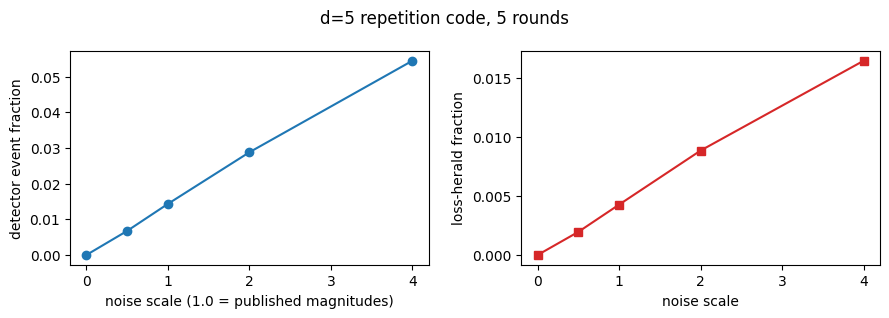

In [11]:
def rep_code(d: int, rounds: int, p_z: float) -> str:
    data = list(range(d))
    anc = list(range(d, 2 * d - 1))
    lines = ["H " + " ".join(map(str, data))]
    for k in range(rounds):
        for i in range(d - 1):
            lines += [f"CX {data[i]} {anc[i]}", f"CX {data[i + 1]} {anc[i]}"]
        lines += [
            "S " + " ".join(map(str, data)),
            f"Z_ERROR({p_z}) " + " ".join(map(str, data)),
            "MR " + " ".join(map(str, anc)),
        ]
        if k > 0:  # compare each ancilla with its previous round
            lines += [f"DETECTOR rec[-{i + 1}] rec[-{i + 1 + (d - 1)}]" for i in range(d - 1)]
    lines.append("M " + " ".join(map(str, data)))
    return "\n".join(lines) + "\n"


def atom_model(scale: float) -> noncomp.Model:
    leak_2q, loss_2q, leak_1q = 1.0e-3 * scale, 3.9e-3 * scale, 1.3e-3 * scale
    return noncomp.Model(
        initial_state=[1 - 0.0095 * scale, 0, 0.0065 * scale, 0.003 * scale, 0],
        transitions={
            "CX": T(
                {
                    (Level.LEAK_E, Level.E): leak_2q,
                    (Level.LOST, Level.E): loss_2q,
                    (Level.LEAK_G, Level.G): 1e-4 * scale,
                }
            ),
            "S": T({(Level.LEAK_E, Level.E): leak_1q}),
        },
        classifier=ternary_classifier(leak_confusion=0.028),
        reset_restores_lost=True,  # a fresh atom is loaded at ancilla reset
        unknown_source_policy="equalize_rates",
        lost_leaked_ops="drop",
    )


P_Z_OVERROT = twirl.rotation("Z", 0.012 * np.pi / 2)[2]
D, ROUNDS = 5, 5
text = rep_code(D, ROUNDS, P_Z_OVERROT)

scales = [0.0, 0.5, 1.0, 2.0, 4.0]
det_rate, herald_rate = [], []
for s in scales:
    r = noncomp.sample(text, atom_model(s), shots=4000, seed=10)
    det_rate.append(float(r.detectors.mean()))
    herald_rate.append(float(r.heralds.mean()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax1.plot(scales, det_rate, "o-")
ax1.set_xlabel("noise scale (1.0 = published magnitudes)")
ax1.set_ylabel("detector event fraction")
ax2.plot(scales, herald_rate, "s-", color="tab:red")
ax2.set_xlabel("noise scale")
ax2.set_ylabel("loss-herald fraction")
fig.suptitle(f"d={D} repetition code, {ROUNDS} rounds")
fig.tight_layout()
plt.show()

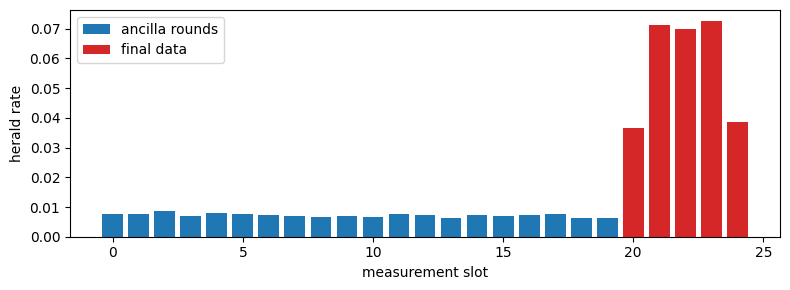

In [12]:
# Where do the heralds land? Data qubits accumulate loss across rounds (no reset);
# ancillas are reloaded each round, so their herald rate stays flat.
r = noncomp.sample(text, atom_model(4.0), shots=20000, seed=11)
n_anc_slots = (D - 1) * ROUNDS
slot_rate = r.heralds.mean(axis=0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(n_anc_slots), slot_rate[:n_anc_slots], label="ancilla rounds")
ax.bar(
    range(n_anc_slots, n_anc_slots + D),
    slot_rate[n_anc_slots:],
    color="tab:red",
    label="final data",
)
ax.set_xlabel("measurement slot")
ax.set_ylabel("herald rate")
ax.legend()
fig.tight_layout()
plt.show()

In [13]:
# Cost of the noncomputational path: the trajectory is resolved before compilation,
# so each shot pays a rewrite + recompile. (Tracked over time in the repository's
# nightly benchmark suite.)
import time

plain = clifft.compile(text)
t0 = time.perf_counter()
clifft.sample(plain, 2000, 1)
t_plain = time.perf_counter() - t0

model = atom_model(1.0)
noncomp.sample(text, model, shots=2, seed=1)  # warm
t0 = time.perf_counter()
noncomp.sample(text, model, shots=500, seed=1)
t_nc = time.perf_counter() - t0
print(f"plain sampling:      {t_plain / 2000 * 1e3:8.4f} ms/shot")
print(f"noncomputational:    {t_nc / 500 * 1e3:8.4f} ms/shot  (per-shot rewrite + compile)")

plain sampling:        0.0002 ms/shot
noncomputational:      0.1085 ms/shot  (per-shot rewrite + compile)


## 4. How this is validated

The checks in this notebook are the demonstration layer of a larger ladder in the
repository's test suite:

- **lossless-limit equivalence** -- a zero-noise model reproduces plain sampling and the
  exact record layout;
- **analytic micro-cases** -- the Bell-pair partial trace, relaxation mixtures, and
  classifier distributions asserted against closed forms (several reproduced above);
- **an independent density-matrix oracle** -- a tiny first-principles simulator, written
  against none of clifft's internals, that cross-checks output distributions on the
  supported subset in CI;
- **divergence probes** -- the two documented approximations of section 2.5 are pinned
  quantitatively (the Bell-pair joint gap, the gate-determined miss) so they can never
  soften without a test changing.

## 5. Capability summary

**Exact today** (within clifft's exact near-Clifford simulation):

| mechanism | section |
|---|---|
| initial level populations | 2.1 |
| loss with partial-trace back-action; gates dropped at lost sites | 2.2, 2.6 |
| state-independent leakage/loss transitions on any state | 2.2 |
| state-dependent transitions on instruction-known states | -- |
| computational destinations: relaxation, recapture, re-preparation | 2.3 |
| measurement classifiers, confusion, ternary loss herald, detector wiring | 2.4 |
| Pauli/readout noise alongside the above | 2.7 |
| coherent control errors simulated exactly (active-rank cost) | 2.7 |

**Approximate, by explicit opt-in, with the approximation characterized:**

| mechanism | nature of the approximation |
|---|---|
| state-dependent transitions on unknown states (`equalize_rates`) | marginals exact for unbiased sources; destination-collapse correlations discarded (2.5a); gate-determined-but-untracked states take the approximate path (2.5b) |
| coherent errors as twirled Pauli channels (`clifft.twirl`) | preserves the Pauli-transfer-matrix diagonal, not circuit statistics (2.7) |

**Out of scope** (and why):

- *Exact state-dependent jumps on unknown states* -- requires the destination to depend
  on a runtime measurement outcome; the designated successor is a segmented execution
  tier where precompiled continuations are selected at runtime, which would also restore
  the correlations of 2.5a and remove the equalization dephasing entirely.
- *Movement / atom-site semantics, correlated multi-qubit leakage instruments* -- per-qubit
  marginal transition matrices only, today.
- *Asymmetric computational readout confusion* -- symmetric flips via noise instructions,
  or classical post-processing for terminal measurements.

The pattern throughout: anything clifft cannot do exactly is **refused by default** and
available only behind a named policy knob whose approximation is documented and pinned by
tests -- so a simulation either is exact, or says precisely how it is not.

## Appendix: translating from cirq-superstaq's leakage simulator

For readers coming from the transition-matrix leakage simulator in cirq-superstaq, the
two models share their core structure -- a stabilizer-class quantum core plus a
classical per-qubit level tracker -- and most concepts carry over one to one:

| there | here | section |
|---|---|---|
| five-level qudit, indices 0--4 | the same five levels, named by `noncomp.Level` | 1 |
| `JumpChannel` matrix, entry = P(from column to row), column deficit = no jump | identical convention: `transitions={"GATE": T}` | 1 |
| channels attached to CZ / Z-rotations | any gate name can carry a matrix (`"CZ"`, `"S"`, `"CX"`, ...) | 3 |
| initial-state preparation channel | `initial_state=[...]` | 2.1 |
| classifier errors with ternary readout (0 / 1 / loss) | three-symbol `Classifier`; the visible record stays binary and the loss symbol arrives in the `heralds` sidecar; `symbols()` reconstructs the ternary view | 2.4 |
| equalize-and-collapse for jumps on superposed qubits | `unknown_source_policy="equalize_rates"` -- refused by default, opt-in, with the approximation characterized | 2.5 |
| gates skipped on leaked or lost atoms | `lost_leaked_ops="drop"` -- refused by default, opt-in | 2.6 |
| reset reloads a lost atom | `reset_restores_lost=True` | 2.6, 3 |
| over-rotations twirled onto the stabilizer sampler | `clifft.twirl` produces the same Pauli channel as explicit noise instructions -- or simulate the rotation exactly | 2.7 |
| `cirq.Circuit` input | Stim-format text (or a parsed `clifft.Circuit`); measurement keys become record slots, and `DETECTOR` / `OBSERVABLE_INCLUDE` are evaluated in-circuit | 2.4, 3 |

Section 3's `atom_model` is exactly this translation applied to published neutral-atom
parameter magnitudes.

**Differences to plan around, in both directions.** Not available here: oversampling
amortization (clifft's per-shot pipeline cost is low enough not to need it -- see the
timing cell in section 3); noise hooks on global-rotation or atom-movement operations
(no atom-site semantics); asymmetric readout confusion on *computational* levels
(symmetric flips via noise instructions, or classical post-processing for terminal
measurements); and a readout that collapses the level register -- the classifier here is
record-only, the tracked status is unchanged by measurement. Available here that has no
direct counterpart there: detectors and observables computed in-circuit from classifier
outcomes, a record layout that is invariant under every loss/leakage event (decoder
inputs never reshape), per-qubit final-status and per-slot herald sidecars, exact
simulation of non-Clifford and coherent-error gates, and reproducible per-shot seeding.